 Step1- Install PyTorch

In [ ]:
pip install torch torchvision numpy matplotlib

Step 2- The perceptron in pure Python (no libaries)

In [ ]:
import numpy as np

# A single perceptron — completely from scratch
class Perceptron:
    def __init__(self, n_inputs, lr=0.1):
        # Random small weights + one bias
        self.weights = np.random.randn(n_inputs) * 0.01
        self.bias = 0.0
        self.lr = lr

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def predict(self, x):
        # z = w1*x1 + w2*x2 + ... + b
        z = np.dot(self.weights, x) + self.bias
        return self.sigmoid(z)

    def train_one_step(self, x, y_true):
        # Forward pass
        y_pred = self.predict(x)

        # Error
        error = y_true - y_pred

        # Update weights (gradient descent — we'll go deep on this Day 4)
        self.weights += self.lr * error * x
        self.bias    += self.lr * error

        return error

# Test it on the "hiring" problem
p = Perceptron(n_inputs=3)

# Training data: [experience, skills, education] → hire (1) or not (0)
training_data = [
    ([0.9, 0.8, 0.7], 1),  # strong candidate → hire
    ([0.1, 0.2, 0.3], 0),  # weak candidate → don't hire
    ([0.7, 0.9, 0.4], 1),
    ([0.2, 0.1, 0.5], 0),
]

print("Training...\n")
for epoch in range(20):
    total_error = 0
    for x, y in training_data:
        err = p.train_one_step(np.array(x), y)
        total_error += abs(err)
    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d} | Total error: {total_error:.4f}")

print("\nFinal weights:", np.round(p.weights, 3))
print("Final bias   :", round(p.bias, 3))
print("\nPredictions:")
for x, y in training_data:
    pred = p.predict(np.array(x))
    print(f"  Input {x} → pred: {pred:.3f} | truth: {y} | {'✓' if round(pred)==y else '✗'}")

Training...

Epoch  0 | Total error: 2.0204
Epoch  5 | Total error: 1.8236
Epoch 10 | Total error: 1.6769
Epoch 15 | Total error: 1.5540

Final weights: [0.851 0.923 0.023]
Final bias   : -0.553

Predictions:
  Input [0.9, 0.8, 0.7] → pred: 0.725 | truth: 1 | ✓
  Input [0.1, 0.2, 0.3] → pred: 0.431 | truth: 0 | ✓
  Input [0.7, 0.9, 0.4] → pred: 0.707 | truth: 1 | ✓
  Input [0.2, 0.1, 0.5] → pred: 0.431 | truth: 0 | ✓


Step 3 - Now do it in PyTorch

In [ ]:
import torch
import torch.nn as nn

# PyTorch version — same perceptron, but now the framework handles gradients
class PerceptronTorch(nn.Module):
    def __init__(self, n_inputs):
        super().__init__()
        # nn.Linear does: z = w*x + b  (same as our manual version)
        self.linear = nn.Linear(n_inputs, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.linear(x))

# Data
X = torch.tensor([
    [0.9, 0.8, 0.7],
    [0.1, 0.2, 0.3],
    [0.7, 0.9, 0.4],
    [0.2, 0.1, 0.5],
], dtype=torch.float32)

y = torch.tensor([[1.], [0.], [1.], [0.]])

# Model, loss function, optimizer
model = PerceptronTorch(n_inputs=3)
criterion = nn.BCELoss()             # Binary Cross Entropy for 0/1 problems
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

# Training loop — this is the pattern you'll use for EVERY model
print("Training with PyTorch...\n")
for epoch in range(100):
    # 1. Forward pass
    y_pred = model(X)

    # 2. Compute loss
    loss = criterion(y_pred, y)

    # 3. Zero gradients (IMPORTANT — PyTorch accumulates by default)
    optimizer.zero_grad()

    # 4. Backward pass (autograd computes gradients)
    loss.backward()

    # 5. Update weights
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

print("\nFinal predictions:")
with torch.no_grad():
    preds = model(X)
    for i, (pred, truth) in enumerate(zip(preds, y)):
        print(f"  Sample {i+1}: pred={pred.item():.3f} truth={truth.item():.0f} {'✓' if round(pred.item())==truth.item() else '✗'}")

Training with PyTorch...

Epoch   0 | Loss: 0.7014
Epoch  20 | Loss: 0.3864
Epoch  40 | Loss: 0.2694
Epoch  60 | Loss: 0.2025
Epoch  80 | Loss: 0.1604

Final predictions:
  Sample 1: pred=0.907 truth=1 ✓
  Sample 2: pred=0.159 truth=0 ✓
  Sample 3: pred=0.900 truth=1 ✓
  Sample 4: pred=0.141 truth=0 ✓


Step 4 — Visualize the decision boundary

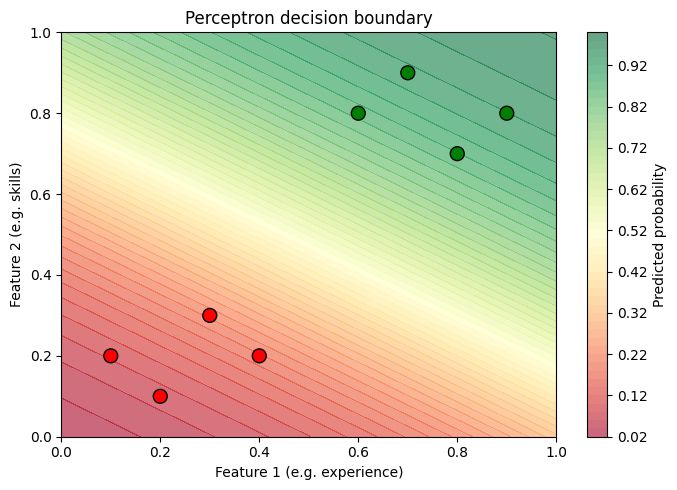

In [ ]:
import matplotlib.pyplot as plt

# Let's visualize what the perceptron learned in 2D
# (using only 2 features so we can plot)

X_2d = torch.tensor([
    [0.9, 0.8], [0.1, 0.2], [0.7, 0.9], [0.2, 0.1],
    [0.8, 0.7], [0.3, 0.3], [0.6, 0.8], [0.4, 0.2],
], dtype=torch.float32)
y_2d = torch.tensor([[1],[0],[1],[0],[1],[0],[1],[0]], dtype=torch.float32)

model_2d = PerceptronTorch(n_inputs=2)
optimizer_2d = torch.optim.SGD(model_2d.parameters(), lr=0.5)

for _ in range(200):
    pred = model_2d(X_2d)
    loss = criterion(pred, y_2d)
    optimizer_2d.zero_grad()
    loss.backward()
    optimizer_2d.step()

# Plot
xx, yy = np.meshgrid(np.linspace(0,1,100), np.linspace(0,1,100))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    Z = model_2d(grid).reshape(xx.shape).numpy()

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, levels=50, cmap='RdYlGn', alpha=0.6)
plt.colorbar(label='Predicted probability')
colors = ['red' if label == 0 else 'green' for label in y_2d.numpy().flatten()]
plt.scatter(X_2d[:,0], X_2d[:,1], c=colors, edgecolors='black', s=100, zorder=5)
plt.xlabel('Feature 1 (e.g. experience)')
plt.ylabel('Feature 2 (e.g. skills)')
plt.title('Perceptron decision boundary')
plt.tight_layout()
plt.show()